In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/dataset_fraude.csv')
df.head()

,id_cliente,tipo_cliente,edad_cliente,customer_country,customer_region,tenure,importe_medio_mensual,desviacion_estandar_mensual,media_transacciones_al_dia,numero_fraudes_ultimo_ano,...,identificador_dispositivo_fingerprint,dispositivo_reconocido,operacion_pais,operacion_region,direccion_ip_origen,geolocalizacion,cuenta_destino,destino_alto_riesgo,IS_FRAUD,IMPACTO_FRAUDE
0,3ddebd45-ccd,empresa,57,ES,Centro,3364,21.97,292.59,1.58,0,...,fa1bdf50-1c95-45,1,ES,Centro,86.34.12.179,"40.4168,-3.7038",ES169540317577,0,0,0
1,12625769-3f8,persona,68,FR,Normandía,2068,283.70,1425.40,2.99,0,...,1d0337cd-8f7a-42,1,FR,Bretaña,90.14.61.52,"48.8566,2.3522",ES735546725072,1,0,0
2,b5768bae-00f,persona,62,PT,Oporto,1671,83.21,537.38,11.62,0,...,0bf03526-6f4e-42,1,PT,Oporto,85.128.118.137,"41.1579,-8.6291",ES833936678283,0,0,0
3,c3a35556-977,persona,79,ES,Este,3436,575.25,270.19,4.76,0,...,29a17329-bcec-42,1,ES,Sur,86.56.138.66,"40.4168,-3.7038",ES642797821786,0,0,0
4,46b228e3-b47,persona,73,DE,Hesse,3557,171.31,302.57,4.00,0,...,5854151e-c36e-41,1,DE,Hesse,87.220.5.4,"52.5200,13.4050",ES973327198270,0,0,0


In [3]:
df.drop(columns=['IMPACTO_FRAUDE'], inplace=True)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 44 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id_cliente                              10000 non-null  str    
 1   tipo_cliente                            10000 non-null  str    
 2   edad_cliente                            10000 non-null  int64  
 3   customer_country                        10000 non-null  str    
 4   customer_region                         10000 non-null  str    
 5   tenure                                  10000 non-null  int64  
 6   importe_medio_mensual                   10000 non-null  float64
 7   desviacion_estandar_mensual             10000 non-null  float64
 8   media_transacciones_al_dia              10000 non-null  float64
 9   numero_fraudes_ultimo_ano               10000 non-null  int64  
 10  id_cuenta                               10000 non-null  str    
 11  c

In [5]:
df.describe()

,edad_cliente,tenure,importe_medio_mensual,desviacion_estandar_mensual,media_transacciones_al_dia,numero_fraudes_ultimo_ano,saldo_actual,saldo_medio_30_dias,volumen_entrante_30_dias,volumen_saliente_30_dias,...,veces_superar_limite_7_dias,is_night,is_weekend,tiempo_desde_ultima_transaccion,numero_transacciones_ultima_hora,importe_transaccion,numero_pin_disponibles,dispositivo_reconocido,destino_alto_riesgo,IS_FRAUD
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,...,10000.000000,10000.00000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,51.228900,1801.225000,860.610553,487.970697,3.345459,0.455700,3339.609429,3283.838537,9065.748711,1.040320e+04,...,0.304200,0.29920,0.284300,1.360110e+06,2.008100,473.109818,1.848100,0.849200,0.118900,0.152600
std,19.861006,1051.031019,1741.871375,476.583989,2.810975,0.784282,9546.123277,9149.502512,24365.369485,4.551894e+04,...,0.548537,0.45793,0.451103,2.956285e+06,1.427459,1177.443036,0.726828,0.357872,0.323687,0.359619
min,18.000000,1.000000,6.930000,0.080000,0.500000,0.000000,1.350000,1.460000,20.660000,1.277000e+01,...,0.000000,0.00000,0.000000,0.000000e+00,0.000000,0.520000,0.000000,0.000000,0.000000,0.000000
25%,34.000000,869.000000,192.380000,147.020000,1.340000,0.000000,401.210000,387.970000,1094.777500,1.132023e+03,...,0.000000,0.00000,0.000000,0.000000e+00,1.000000,54.382500,1.000000,1.000000,0.000000,0.000000
50%,50.000000,1792.000000,430.980000,352.380000,2.500000,0.000000,1024.610000,1043.840000,2964.450000,3.070215e+03,...,0.000000,0.00000,0.000000,4.361600e+04,2.000000,148.475000,2.000000,1.000000,0.000000,0.000000
75%,69.000000,2736.500000,956.230000,681.030000,4.430000,1.000000,2928.127500,2911.290000,8159.335000,8.401372e+03,...,1.000000,1.00000,1.000000,1.579065e+05,3.000000,409.747500,2.000000,1.000000,0.000000,0.000000
max,84.000000,3647.000000,44868.230000,4150.160000,22.450000,6.000000,294122.030000,325718.190000,609238.470000,1.501301e+06,...,4.000000,1.00000,1.000000,1.542519e+07,9.000000,27088.380000,3.000000,1.000000,1.000000,1.000000


In [6]:
df["importe_transaccion"].describe()

count    10000.000000
mean       473.109818
std       1177.443036
min          0.520000
25%         54.382500
50%        148.475000
75%        409.747500
max      27088.380000
Name: importe_transaccion, dtype: float64

In [7]:
print('Columnas del dataset:')
print(df.columns.tolist())

Columnas del dataset:
['id_cliente', 'tipo_cliente', 'edad_cliente', 'customer_country', 'customer_region', 'tenure', 'importe_medio_mensual', 'desviacion_estandar_mensual', 'media_transacciones_al_dia', 'numero_fraudes_ultimo_ano', 'id_cuenta', 'cuenta_origen', 'estado_cuenta', 'saldo_actual', 'saldo_medio_30_dias', 'volumen_entrante_30_dias', 'volumen_saliente_30_dias', 'numero_transferencias_recibidas_7_dias', 'numero_transferencias_enviadas_7_dias', 'id_tarjeta', 'estado_tarjeta', 'fecha_creacion_tarjeta', 'antiguedad_tarjeta_dias', 'limite_importe_transacciones', 'veces_superar_limite_7_dias', 'id_transaccion', 'tipo_transaccion', 'fecha_hora', 'is_night', 'is_weekend', 'tiempo_desde_ultima_transaccion', 'numero_transacciones_ultima_hora', 'importe_transaccion', 'metodo_autenticacion', 'numero_pin_disponibles', 'identificador_dispositivo_fingerprint', 'dispositivo_reconocido', 'operacion_pais', 'operacion_region', 'direccion_ip_origen', 'geolocalizacion', 'cuenta_destino', 'destin

In [8]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print('Columnas categóricas:')
print(categorical_cols)

Columnas categóricas:
['id_cliente', 'tipo_cliente', 'customer_country', 'customer_region', 'id_cuenta', 'cuenta_origen', 'estado_cuenta', 'id_tarjeta', 'estado_tarjeta', 'fecha_creacion_tarjeta', 'id_transaccion', 'tipo_transaccion', 'fecha_hora', 'metodo_autenticacion', 'identificador_dispositivo_fingerprint', 'operacion_pais', 'operacion_region', 'direccion_ip_origen', 'geolocalizacion', 'cuenta_destino']


C:\Users\juan_\AppData\Local\Temp\ipykernel_20324\3080361845.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


Columnas encontradas: ['tipo_cliente', 'customer_country', 'customer_region', 'estado_cuenta', 'estado_tarjeta', 'tipo_transaccion', 'metodo_autenticacion', 'operacion_pais', 'operacion_region']
Columnas no encontradas: []


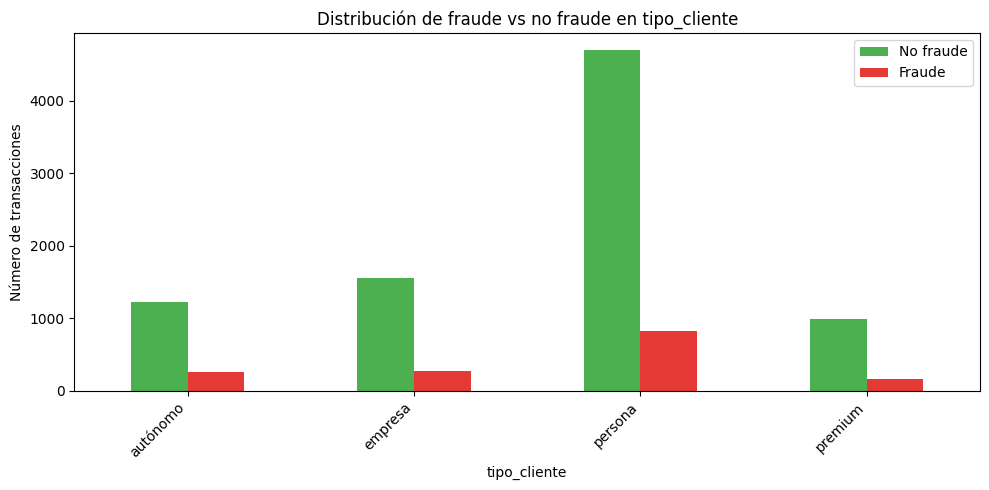

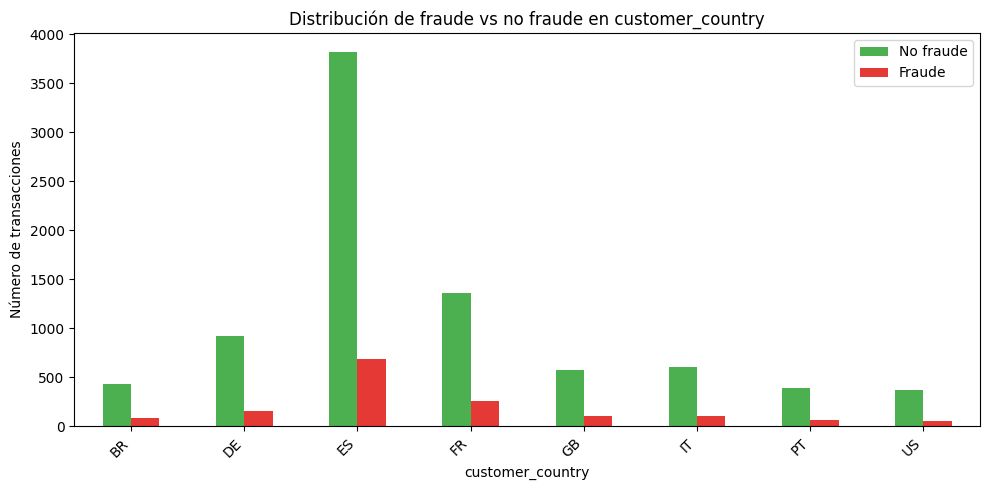

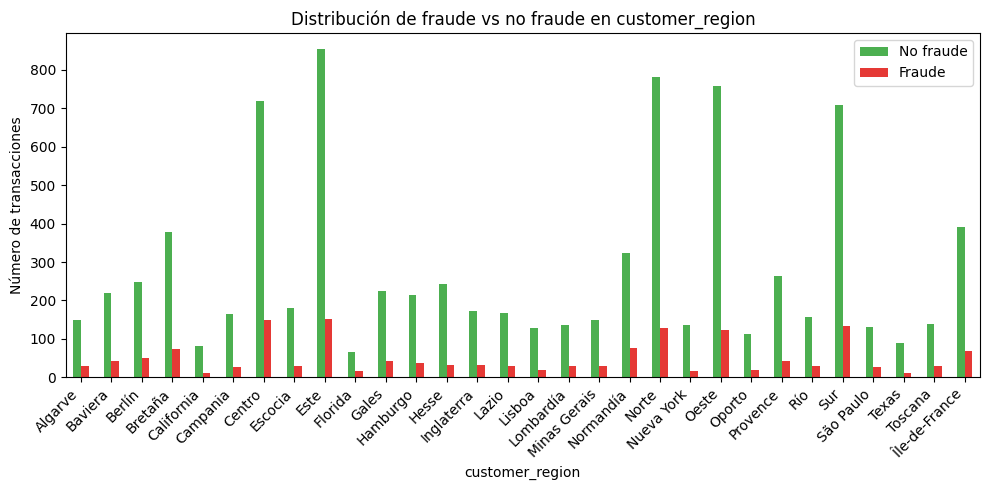

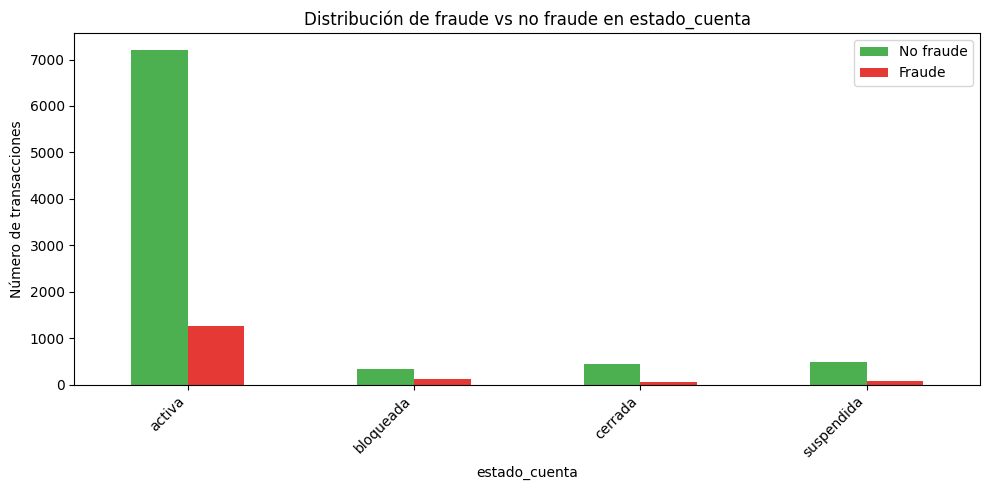

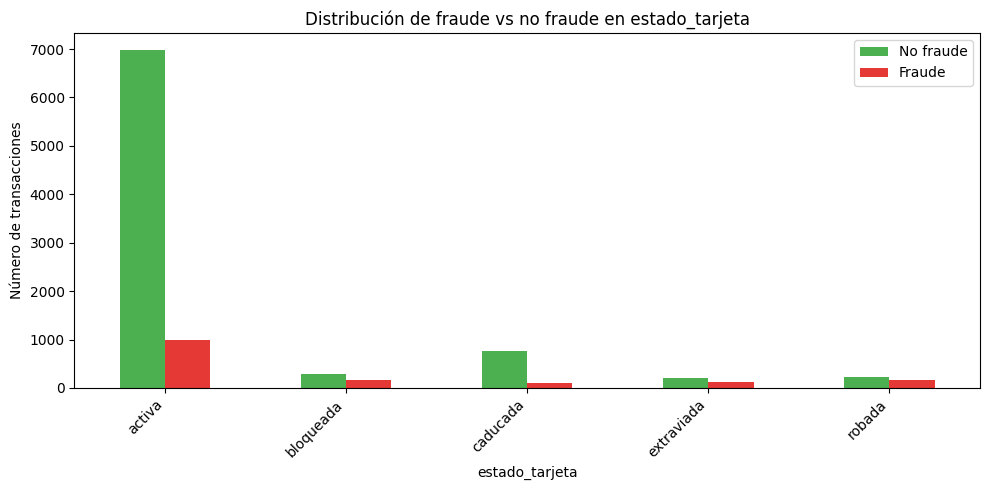

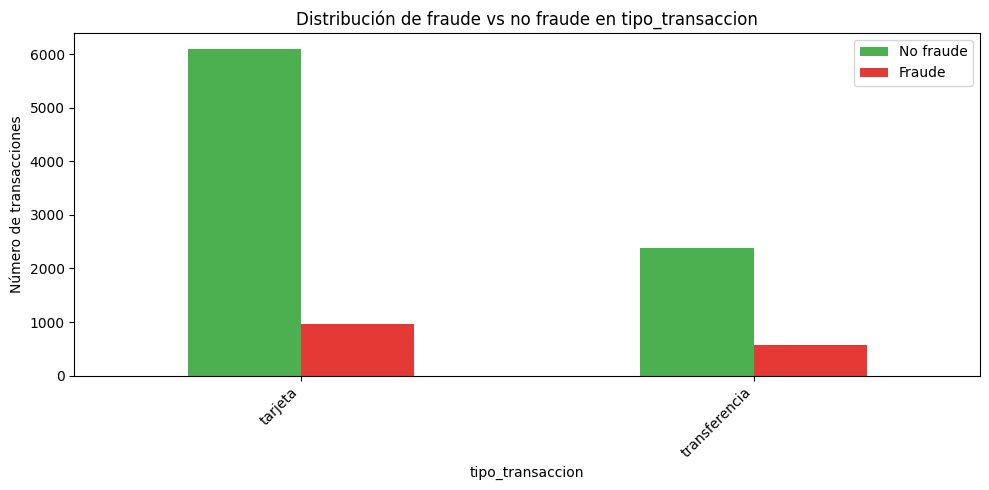

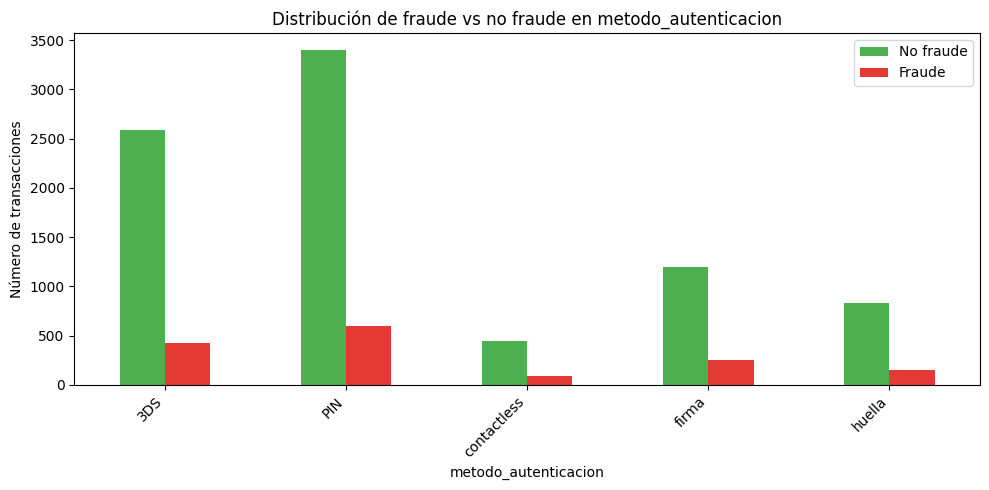

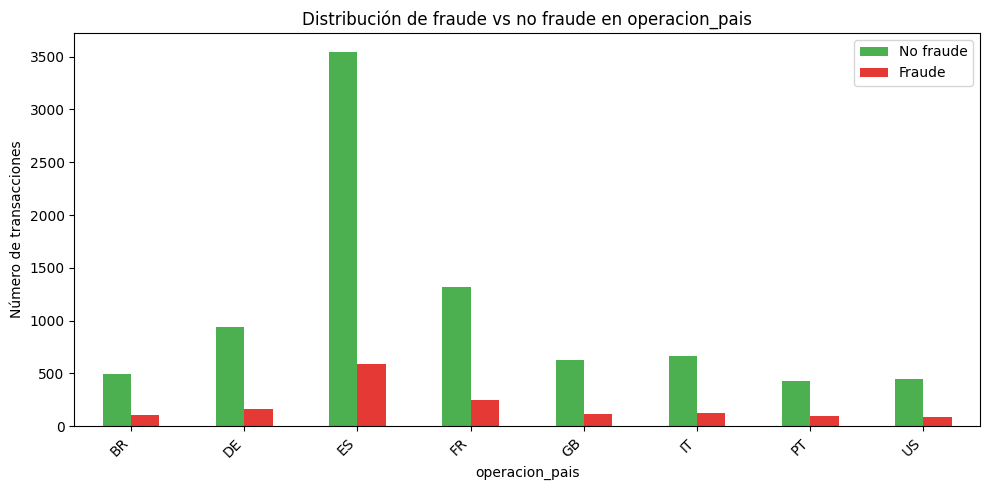

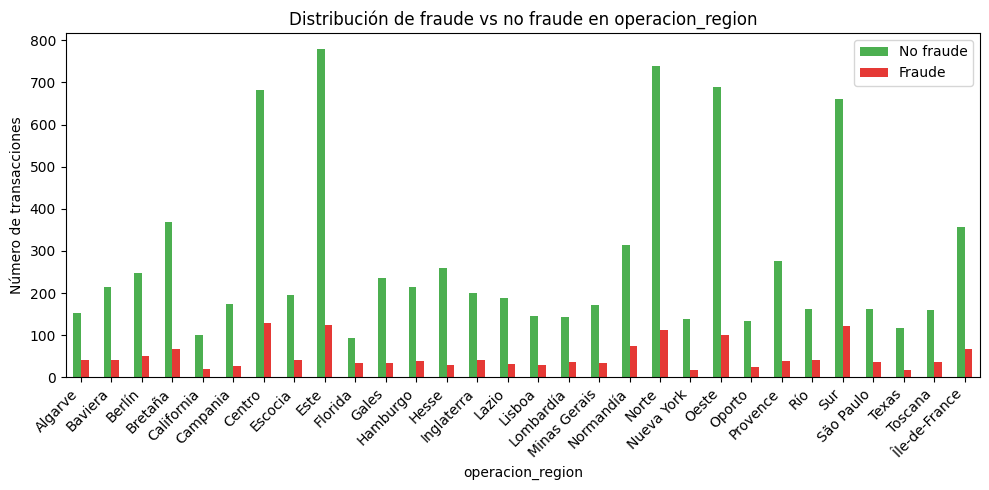

In [9]:
cols_to_plot = [
    'tipo_cliente',
    'customer_country',
    'customer_region',
    'estado_cuenta',
    'estado_tarjeta',
    'tipo_transaccion',
    'metodo_autenticacion',
    'operacion_pais',
    'operacion_region'
]

cols_existentes = [col for col in cols_to_plot if col in df.columns]
cols_faltantes = [col for col in cols_to_plot if col not in df.columns]

print('Columnas encontradas:', cols_existentes)
print('Columnas no encontradas:', cols_faltantes)

for col in cols_existentes:
    tabla = pd.crosstab(df[col], df['IS_FRAUD'])
    tabla = tabla.reindex(columns=[0, 1], fill_value=0)
    tabla.columns = ['No fraude', 'Fraude']

    tabla.plot(kind='bar', figsize=(10, 5), color=['#4CAF50', '#E53935'])
    plt.title(f'Distribución de fraude vs no fraude en {col}')
    plt.xlabel(col)
    plt.ylabel('Número de transacciones')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

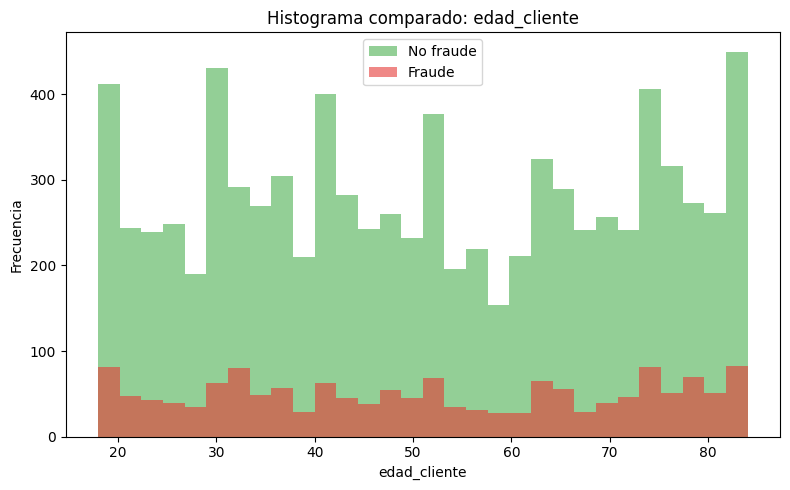

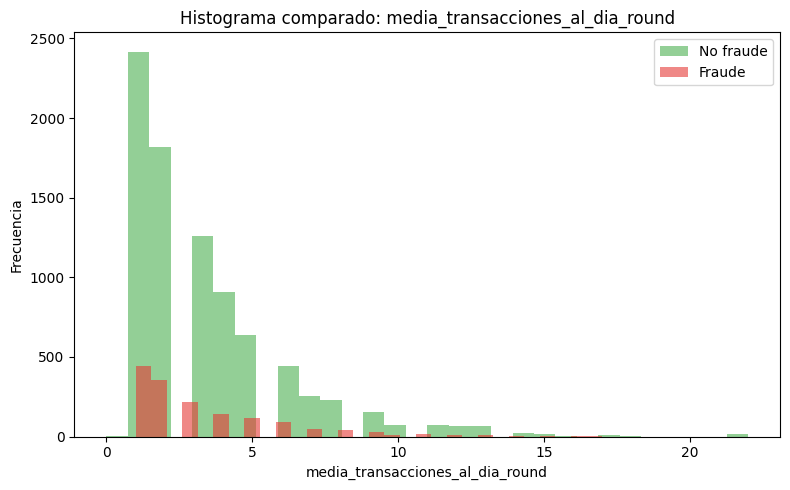

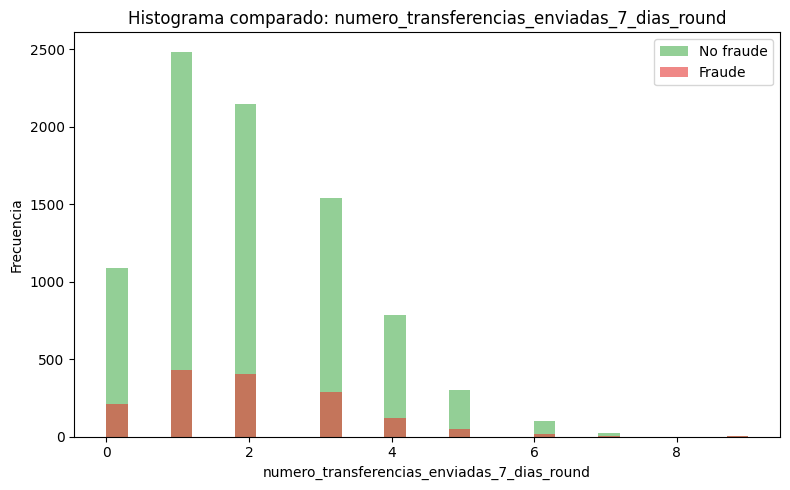

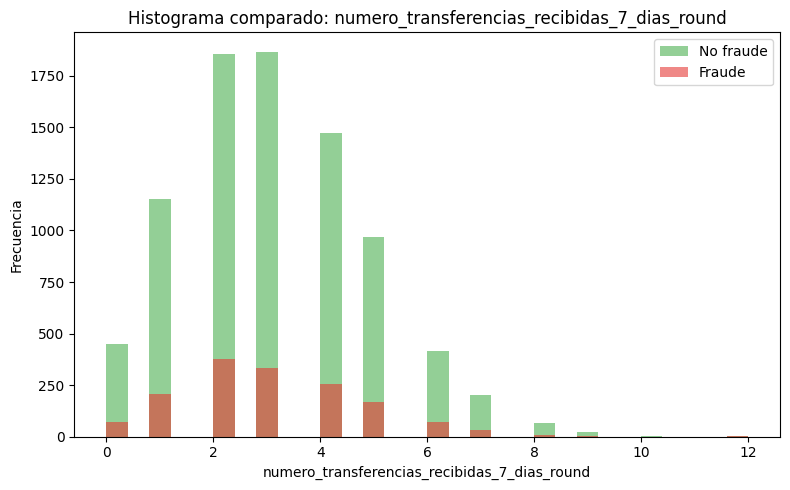

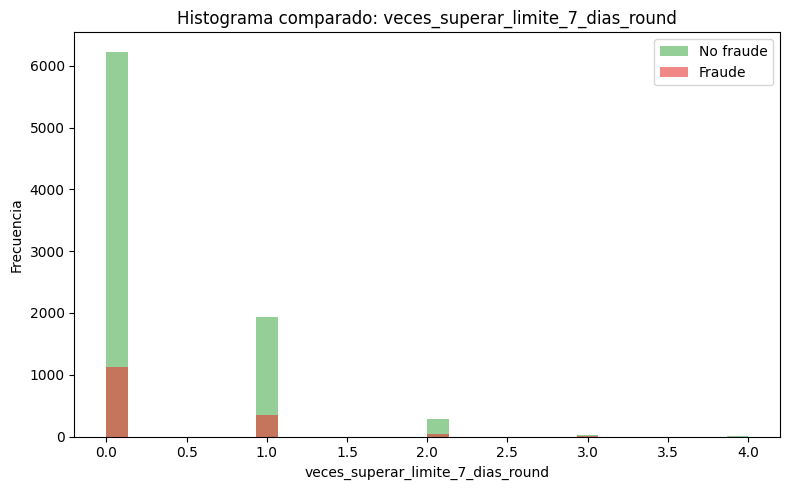

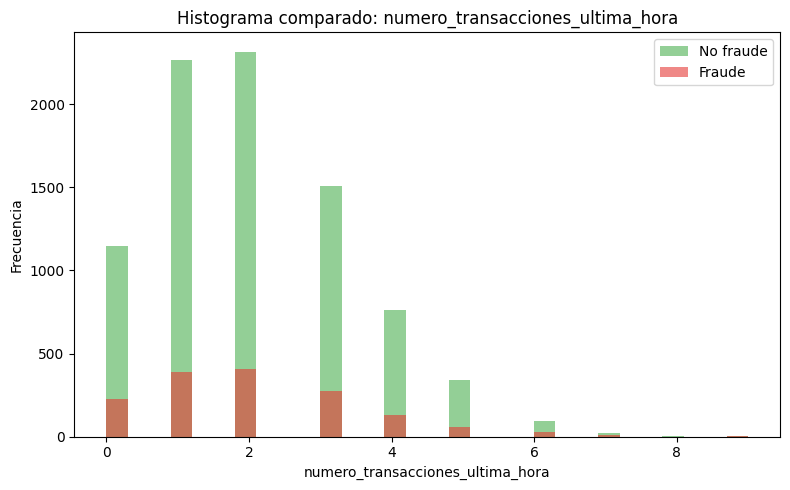

In [10]:
df_plot = df.copy()

df_plot['media_transacciones_al_dia_round'] = df_plot['media_transacciones_al_dia'].round()
df_plot['numero_transferencias_enviadas_7_dias_round'] = df_plot['numero_transferencias_enviadas_7_dias'].round()
df_plot['numero_transferencias_recibidas_7_dias_round'] = df_plot['numero_transferencias_recibidas_7_dias'].round()
df_plot['veces_superar_limite_7_dias_round'] = df_plot['veces_superar_limite_7_dias'].round()

variables = [
    'edad_cliente',
    'media_transacciones_al_dia_round',
    'numero_transferencias_enviadas_7_dias_round',
    'numero_transferencias_recibidas_7_dias_round',
    'veces_superar_limite_7_dias_round',
    'numero_transacciones_ultima_hora'
]

for col in variables:
    plt.figure(figsize=(8, 5))
    
    plt.hist(
        df_plot[df_plot['IS_FRAUD'] == 0][col].dropna(),
        bins=30,
        alpha=0.6,
        label='No fraude',
        color='#4CAF50'
    )
    
    plt.hist(
        df_plot[df_plot['IS_FRAUD'] == 1][col].dropna(),
        bins=30,
        alpha=0.6,
        label='Fraude',
        color='#E53935'
    )
    
    plt.title(f'Histograma comparado: {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.tight_layout()
    plt.show()

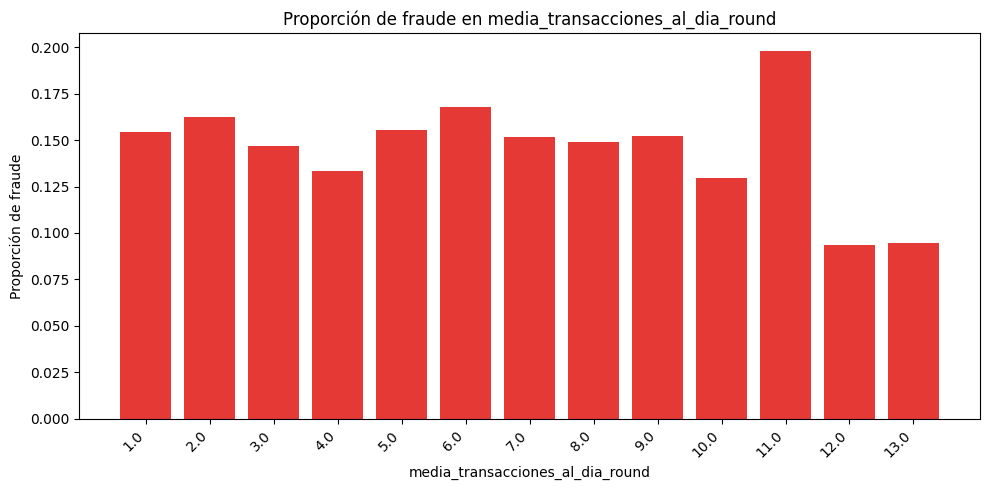

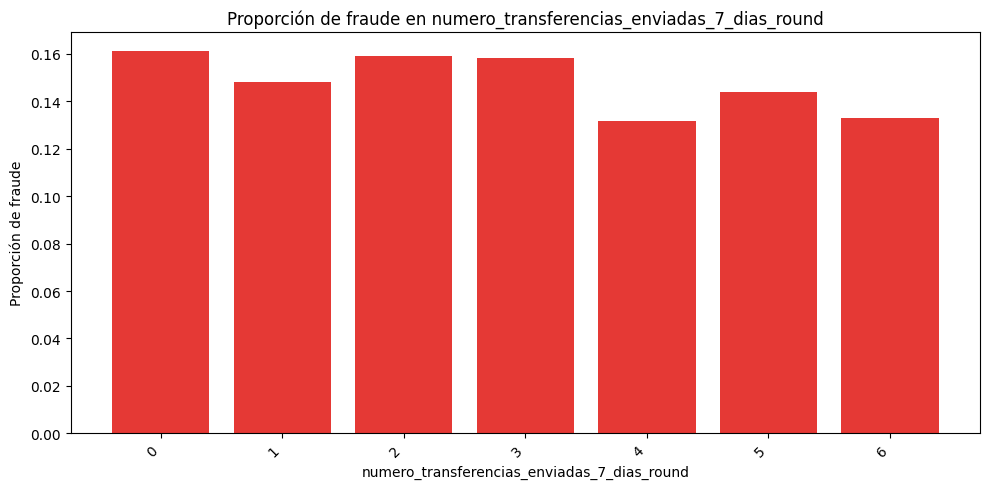

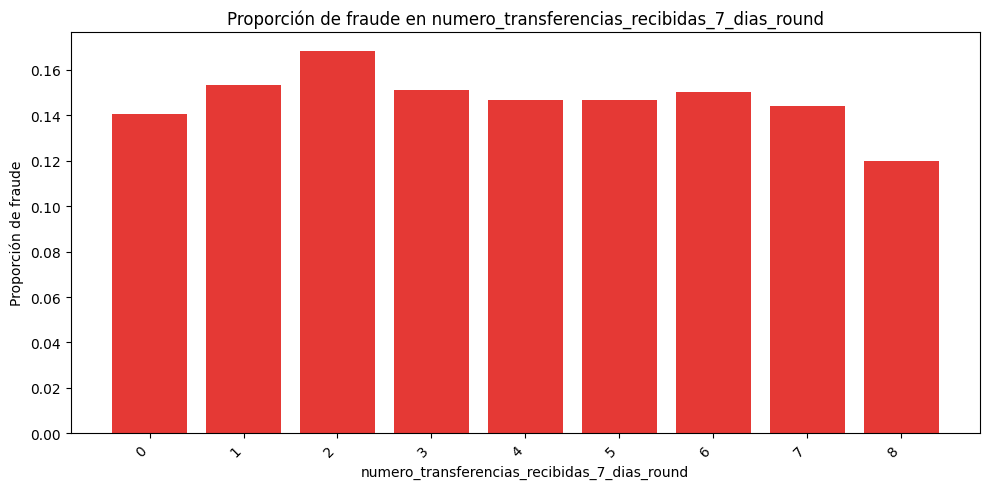

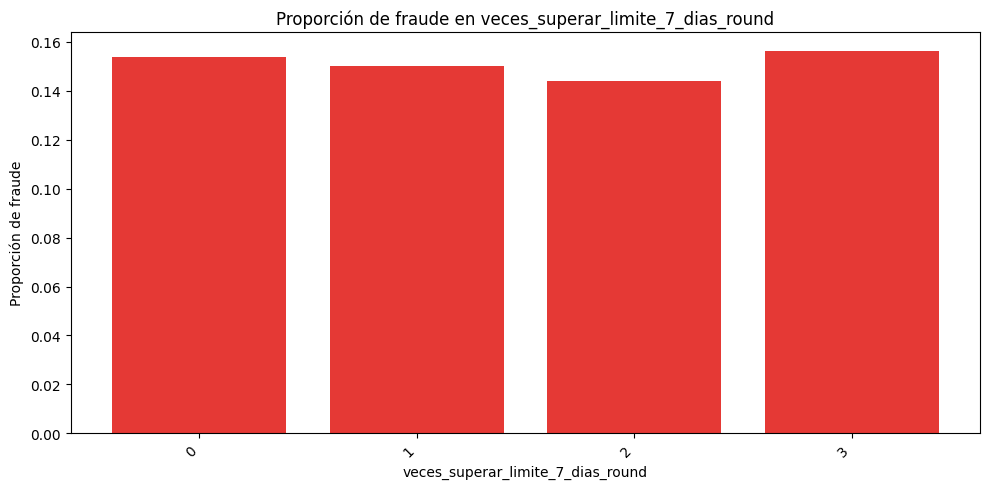

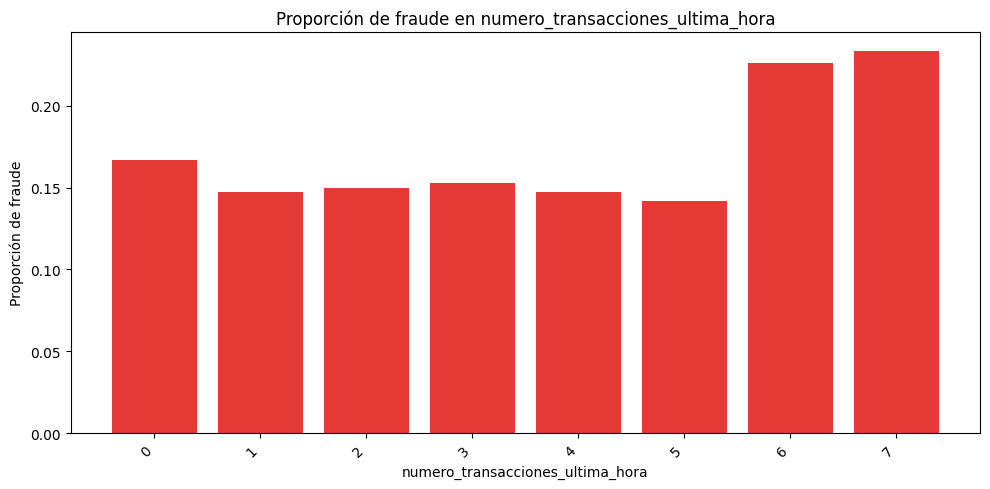

In [11]:
variables = [
    'media_transacciones_al_dia_round',
    'numero_transferencias_enviadas_7_dias_round',
    'numero_transferencias_recibidas_7_dias_round',
    'veces_superar_limite_7_dias_round',
    'numero_transacciones_ultima_hora'
]

min_obs = 30

for col in variables:
    resumen = (
        df_plot.groupby(col, observed=False)
        .agg(
            total=('IS_FRAUD', 'size'),
            fraude_rate=('IS_FRAUD', 'mean')
        )
        .reset_index()
    )

    resumen = resumen[resumen['total'] >= min_obs]
    resumen = resumen.sort_values(col)

    plt.figure(figsize=(10, 5))
    plt.bar(resumen[col].astype(str), resumen['fraude_rate'], color='#E53935')
    plt.title(f'Proporción de fraude en {col}')
    plt.xlabel(col)
    plt.ylabel('Proporción de fraude')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

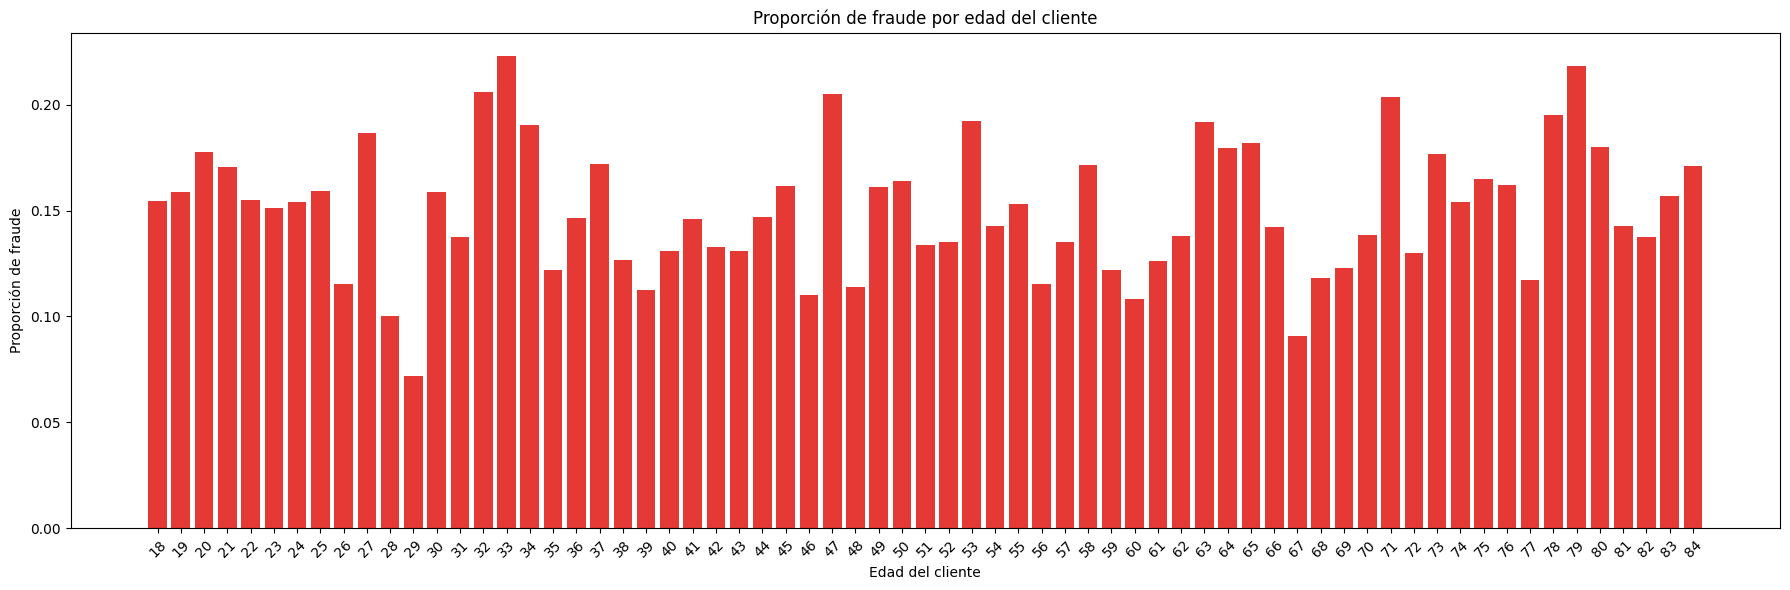

In [12]:
min_obs = 30

resumen_edad = (
    df.groupby('edad_cliente', observed=False)
    .agg(
        total=('IS_FRAUD', 'size'),
        fraude_rate=('IS_FRAUD', 'mean')
    )
    .reset_index()
)

resumen_edad = resumen_edad[resumen_edad['total'] >= min_obs]
resumen_edad = resumen_edad.sort_values('edad_cliente')

plt.figure(figsize=(18, 6))
plt.bar(resumen_edad['edad_cliente'].astype(str), resumen_edad['fraude_rate'], color='#E53935')
plt.title('Proporción de fraude por edad del cliente')
plt.xlabel('Edad del cliente')
plt.ylabel('Proporción de fraude')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
numeric_cols.remove('IS_FRAUD')

corr_target = df[numeric_cols + ['IS_FRAUD']].corr()['IS_FRAUD'].drop('IS_FRAUD')
corr_target = corr_target.sort_values(key=abs, ascending=False)

print(corr_target)

destino_alto_riesgo                       0.187777
dispositivo_reconocido                   -0.086941
importe_transaccion                       0.084366
numero_fraudes_ultimo_ano                 0.038864
importe_medio_mensual                     0.032668
is_night                                  0.013616
numero_pin_disponibles                    0.012932
numero_transferencias_recibidas_7_dias   -0.012812
tenure                                    0.012630
limite_importe_transacciones             -0.012196
numero_transferencias_enviadas_7_dias    -0.010818
media_transacciones_al_dia               -0.010290
saldo_medio_30_dias                       0.009384
saldo_actual                              0.008013
tiempo_desde_ultima_transaccion           0.007846
is_weekend                               -0.007300
desviacion_estandar_mensual               0.006042
antiguedad_tarjeta_dias                  -0.005016
veces_superar_limite_7_dias              -0.004669
edad_cliente                   

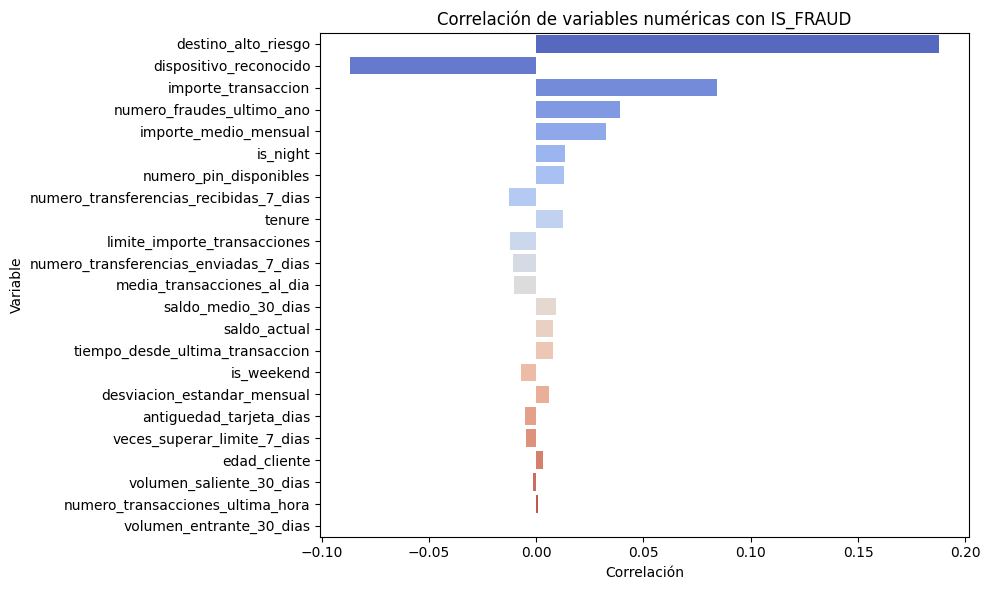

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_target.values, y=corr_target.index, hue=corr_target.index, palette='coolwarm', legend=False)
plt.title('Correlación de variables numéricas con IS_FRAUD')
plt.xlabel('Correlación')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

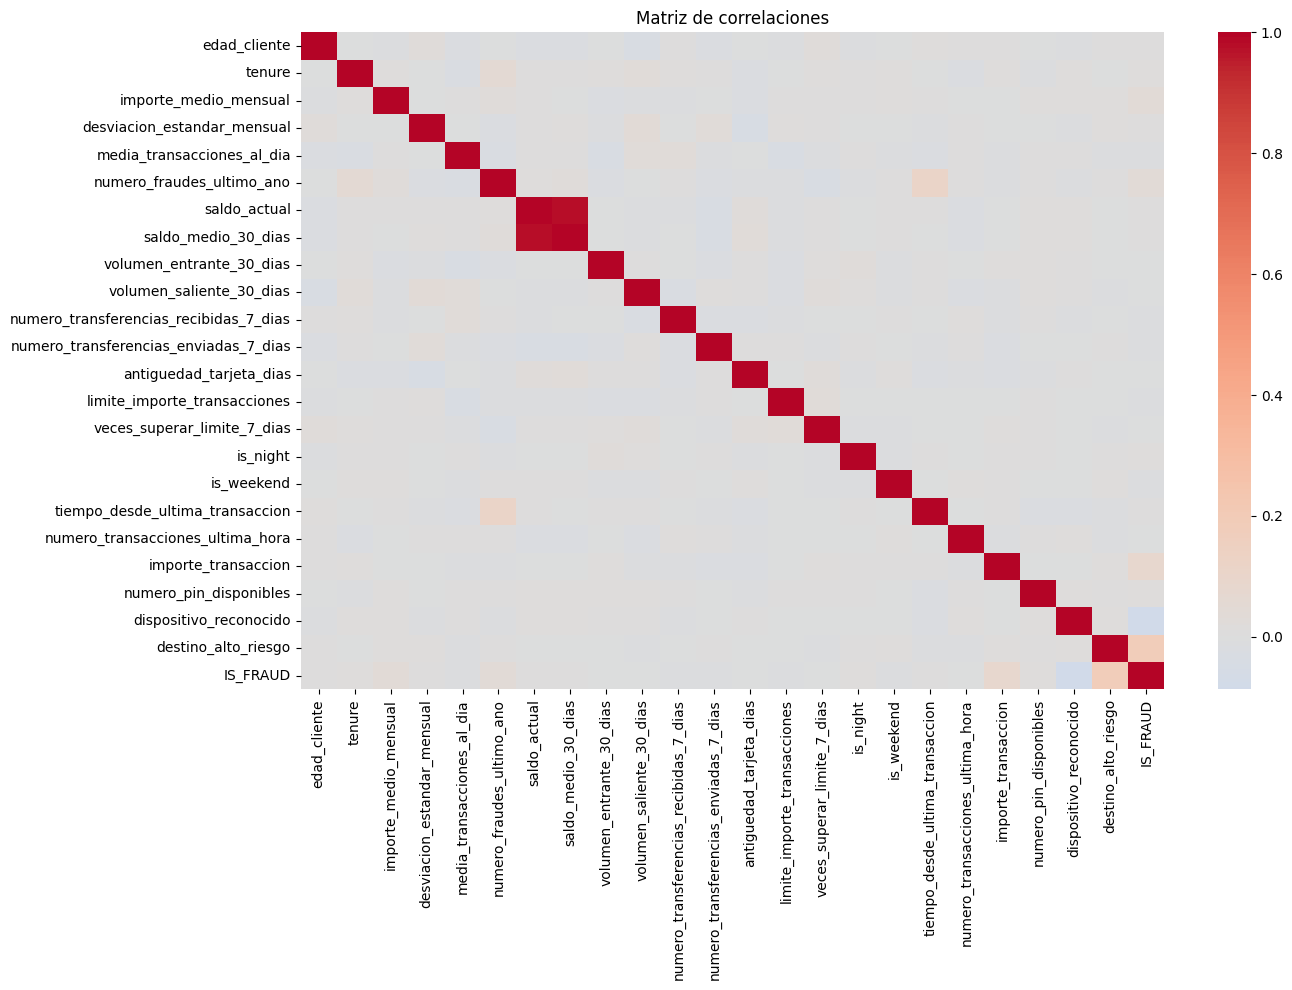

In [15]:
plt.figure(figsize=(14, 10))
sns.heatmap(df[numeric_cols + ['IS_FRAUD']].corr(), cmap='coolwarm', center=0)
plt.title('Matriz de correlaciones')
plt.tight_layout()
plt.show()

In [16]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

# Categóricas útiles para análisis
categorical_cols = [
    col for col in df.select_dtypes(include=['object', 'category']).columns
    if col not in [
        'id_cliente',
        'id_cuenta',
        'id_tarjeta',
        'id_transaccion',
        'direccion_ip_origen',
        'identificador_dispositivo_fingerprint',
        'fecha_hora',
        'fecha_creacion_tarjeta'
    ]
]

def cramers_v(tabla):
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

resultados = []

for col in categorical_cols:
    tabla = pd.crosstab(df[col], df['IS_FRAUD'])
    
    if tabla.shape[0] > 1 and tabla.shape[1] > 1:
        chi2, p_value, _, _ = chi2_contingency(tabla)
        v = cramers_v(tabla)
        
        resultados.append({
            'variable': col,
            'n_categorias': df[col].nunique(),
            'cramers_v': v,
            'p_value': p_value
        })

relacion_categoricas = pd.DataFrame(resultados).sort_values('cramers_v', ascending=False)
relacion_categoricas

C:\Users\juan_\AppData\Local\Temp\ipykernel_20324\2651200233.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col for col in df.select_dtypes(include=['object', 'category']).columns


,variable,n_categorias,cramers_v,p_value
3,cuenta_origen,3548,0.606808,5.561384e-02
11,cuenta_destino,500,0.289926,7.846106e-20
5,estado_tarjeta,5,0.226387,1.317423e-109
4,estado_cuenta,4,0.075266,3.052935e-12
9,operacion_region,30,0.073500,3.216245e-03
6,tipo_transaccion,2,0.072147,5.407263e-13
10,geolocalizacion,25,0.051207,3.420280e-01
2,customer_region,30,0.046802,8.241396e-01
8,operacion_pais,8,0.034475,1.044024e-01
7,metodo_autenticacion,5,0.032056,3.602751e-02


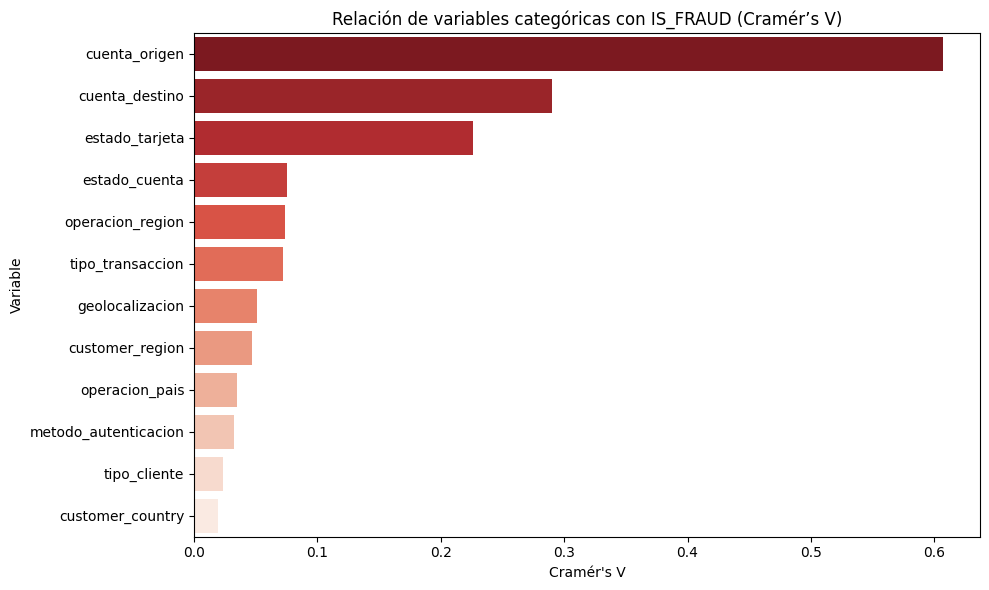

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=relacion_categoricas,
    x='cramers_v',
    y='variable',
    hue='variable',
    palette='Reds_r',
    legend=False
)
plt.title('Relación de variables categóricas con IS_FRAUD (Cramér’s V)')
plt.xlabel("Cramér's V")
plt.ylabel('Variable')
plt.tight_layout()
plt.show()